# Exploratory Data Analysis & Feature Engineering Comparison

In this notebook, we compare the correlation patterns in the Maternal Health Risk dataset before and after applying clinical feature engineering.

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Set Seaborn theme for premium aesthetics
sns.set_theme(style="whitegrid", palette="magma")

# Load the real dataset
data_path = os.path.join("..", "data", "Maternal Health Risk Data Set.csv")
df = pd.read_csv(data_path)

# Encode RiskLevel for correlation analysis
risk_map = {'low risk': 0, 'mid risk': 1, 'high risk': 2}
df_encoded = df.copy()
df_encoded['RiskLevel'] = df_encoded['RiskLevel'].map(risk_map)

print("Data loaded and target encoded.")
df.head()

Data loaded and target encoded.


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


## 1. Class Distribution

Using Seaborn's `countplot` to visualize the frequency of each risk category.

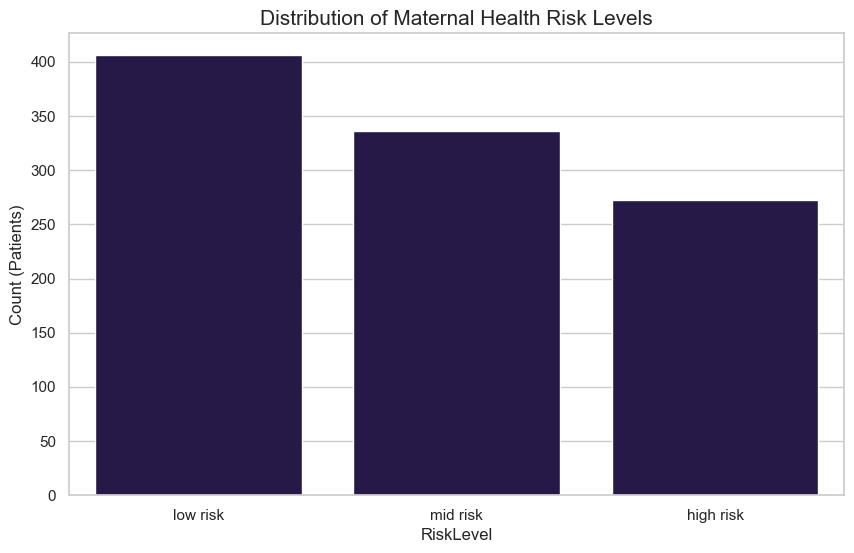

In [13]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='RiskLevel', order=['low risk', 'mid risk', 'high risk'])
plt.title("Distribution of Maternal Health Risk Levels", fontsize=15)
plt.ylabel("Count (Patients)")
plt.show()

## 2. Feature Distribution by Risk Level

Analyzing how key physiological metrics vary across different risk categories using Seaborn `boxplots`.

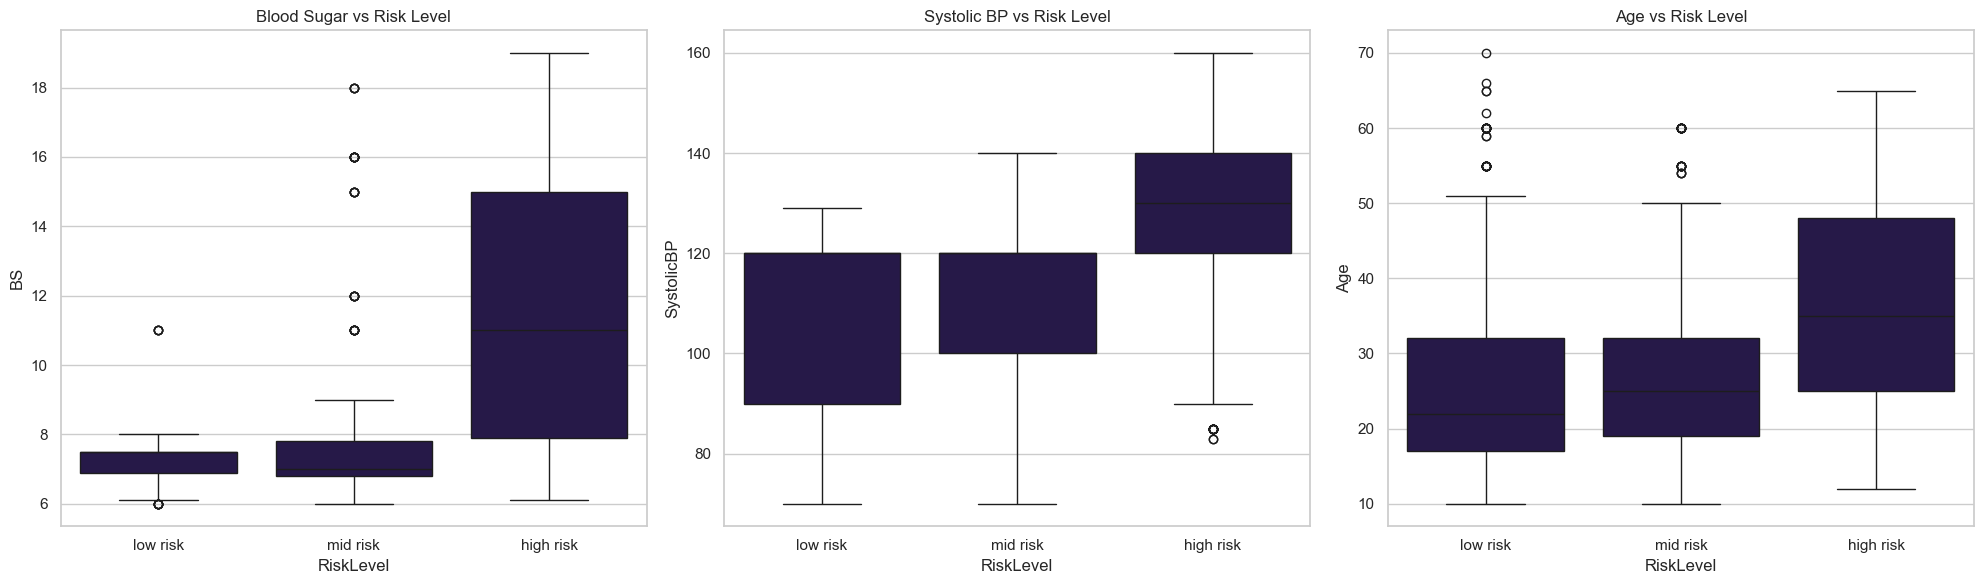

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.boxplot(ax=axes[0], data=df, x='RiskLevel', y='BS', order=['low risk', 'mid risk', 'high risk'])
axes[0].set_title("Blood Sugar vs Risk Level")

sns.boxplot(ax=axes[1], data=df, x='RiskLevel', y='SystolicBP', order=['low risk', 'mid risk', 'high risk'])
axes[1].set_title("Systolic BP vs Risk Level")

sns.boxplot(ax=axes[2], data=df, x='RiskLevel', y='Age', order=['low risk', 'mid risk', 'high risk'])
axes[2].set_title("Age vs Risk Level")

plt.tight_layout()
plt.show()

## 3. Correlation Matrix: BEFORE Feature Engineering

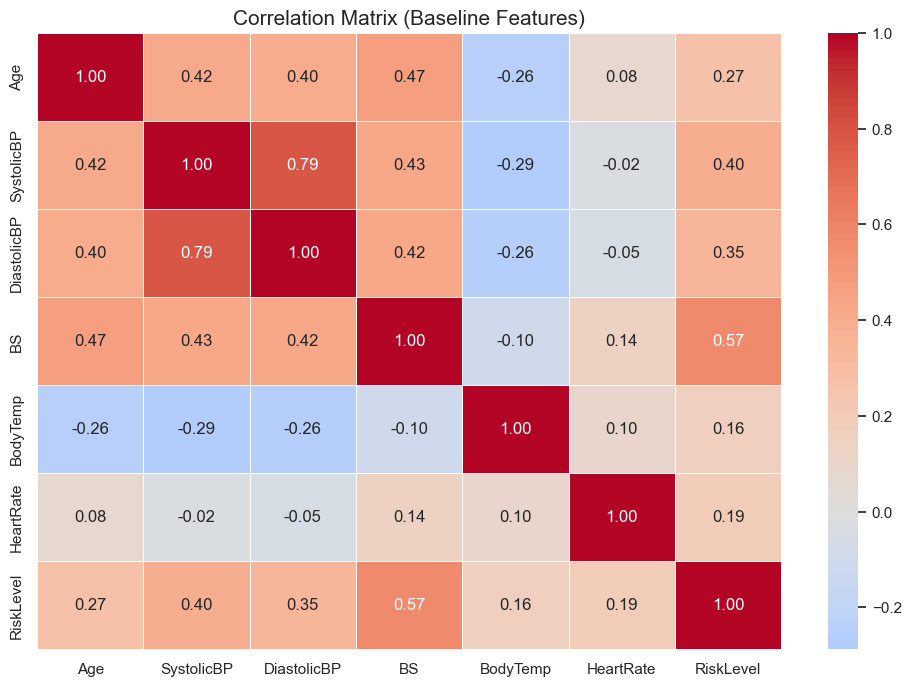

In [15]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix (Baseline Features)", fontsize=15)
plt.show()

## 4. Applying Feature Engineering

We apply clinical metrics such as Mean Arterial Pressure (MAP), Pulse Pressure, and Shock Index.

In [16]:
# Clinical Feature Engineering
df_encoded["MAP"] = (df_encoded["SystolicBP"] + 2 * df_encoded["DiastolicBP"]) / 3
df_encoded["PulsePressure"] = df_encoded["SystolicBP"] - df_encoded["DiastolicBP"]
df_encoded["ShockIndex"] = df_encoded["HeartRate"] / df_encoded["SystolicBP"]
df_encoded["BPRatio"] = df_encoded["SystolicBP"] / df_encoded["DiastolicBP"]

# Use temporary variables for deviations to keep the dataset clean from redundant features
temp_dev = df_encoded["BodyTemp"] - 98.2

df_encoded["CombinedRiskScore"] = (
    (df_encoded["MAP"] > 105).astype(int) +
    (df_encoded["BS"] > 10).astype(int) +
    (df_encoded["HeartRate"] > 90).astype(int) +
    (temp_dev > 1).astype(int)
)

print("Feature engineering complete. (Redundant columns BSDeviation/TempDeviation removed)")

Feature engineering complete.


## 5. Correlation Matrix: AFTER Feature Engineering

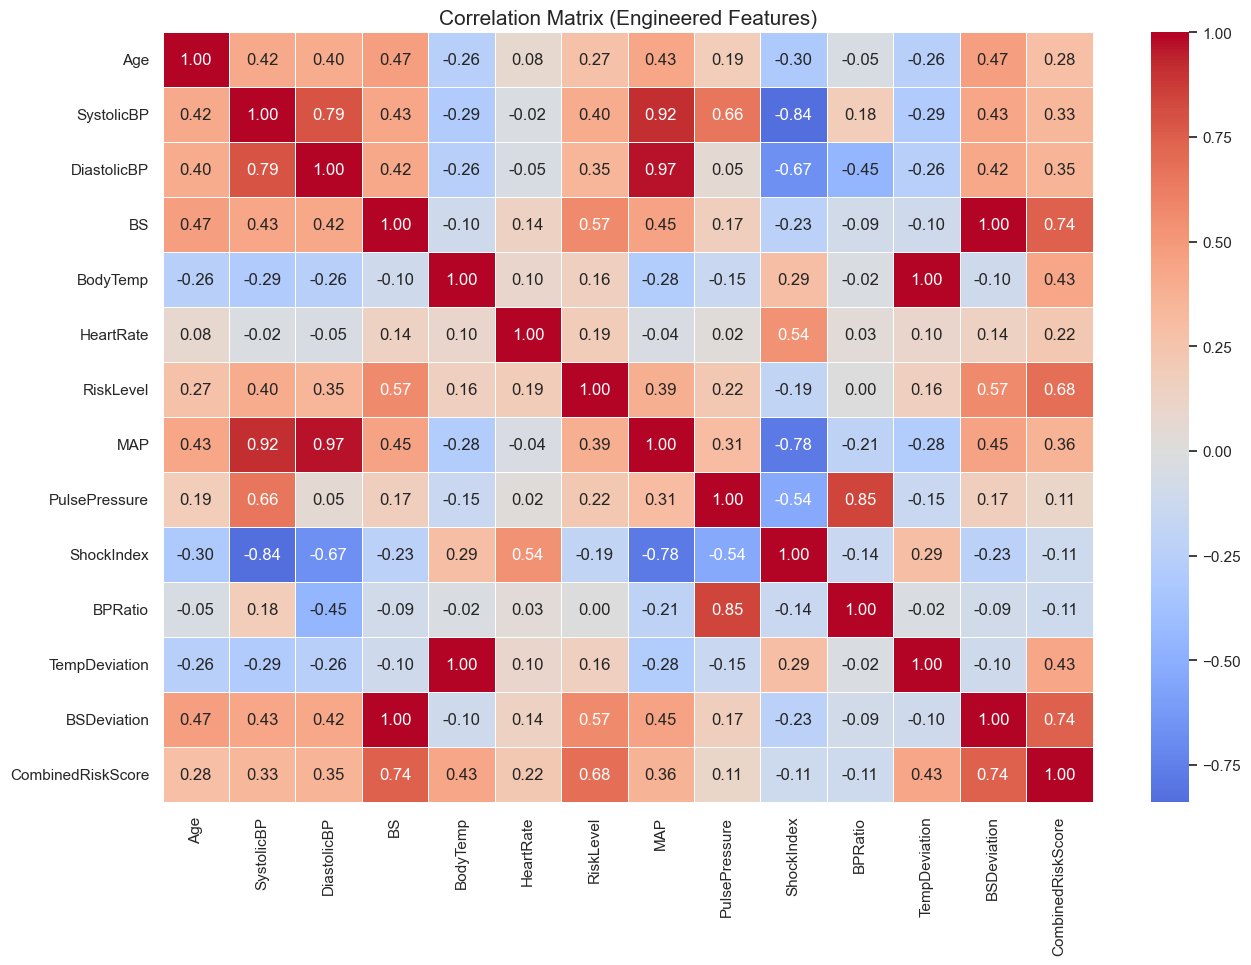

In [17]:
plt.figure(figsize=(15, 10))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix (Engineered Features)", fontsize=15)
plt.show()